In [2]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]


In [63]:
# 3DVARクラスの定義
class ThreeDVar:
    """
    3次元変分法 (3DVAR) クラス
    """
    def __init__(self, N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=None, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0):
        """
        3次元変分法の初期化

        Parameters:
        -----------
        N : int
            状態変数の数
        F : float
            外部強制力
        dt : float
            時間ステップ
        H : ndarray
            観測演算子
        obs_error_std : float
            観測誤差の標準偏差
        forecast_error_std : float
            予報誤差の標準偏差(定数として使用可能)
        model_error_std : float
            モデル誤差の標準偏差
        use_constant_P : bool
            予報誤差共分散を定数として扱うか(True=3次元変分法と同値)
        method : str
            時間積分メソッド ('euler', 'rk2', 'rk4')
        way : str
            接線線形演算子の計算方法 ('Numerical', 'Mathematical')
        delta : float
            接線線形演算子の数値微分の差分幅(ヤコビ行列計算用)
        inflation_factor : float
            予報誤差共分散行列のインフレーション係数
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.obs_error_std = obs_error_std
        self.forecast_error_std = forecast_error_std
        self.H = H
        self.use_constant_P = use_constant_P
        self.method = method
        self.way = way
        self.delta = delta
        self.inflation_factor = inflation_factor

        # StateArrayクラスのインスタンス化
        self.state_array = StateArray(N, F, dt, method=method)
        
        # 観測誤差共分散行列
        self.R = obs_error_std * np.eye(N)
        
        # 予報誤差共分散行列
        self.P_analysis = forecast_error_std * np.eye(N)
        self.P_forecast = None
        self.P_constant = forecast_error_std * np.eye(N)  # 定数として保存
        
        
        # 状態変数の初期化
        self.x_analysis = None
        self.x_forecast = None
        
        # 履歴の保存
        self.analysis_history = []
        self.forecast_history = []
        self.innovation_history = []
        self.P_history = []  # 予報誤差共分散行列の履歴
        
    def initialize_state(self, x0):
        """
        初期状態の設定
        
        Parameters:
        -----------
        x0 : ndarray
            初期状態ベクトル
        """
        self.x_analysis = x0.copy()
        if self.H.any():
            self.R = self.obs_error_std * np.eye(self.H.shape[0])
        
    def compute_tangent_linear(self, x, way='Numerical'):
        """
        Lorenz96モデルの接線形演算子(ヤコビ行列)を計算
        
        Parameters:
        -----------
        x : ndarray
            状態ベクトル
            
        Returns:
        --------
        M : ndarray
            接線形演算子行列
        """
        if way == 'Numerical':
            N = len(x)
            M = np.zeros((N, N))
            e = np.eye(N)
            delta = self.delta
            temp_state = StateArray(N, self.F, self.dt, method=self.method)
            temp_state.x = x.copy()
            temp_state.step()
            f = temp_state.x.copy()
            for i in range(N):
                x_plus = x.copy()
                x_plus += delta * e[:, i]
                temp_state.x = x_plus.copy()
                temp_state.step()
                f_plus = temp_state.x.copy()

                M[:, i] = (f_plus - f) / delta
            
            return M
        
        elif way == 'Mathematical':
            N = len(x)
            M = np.zeros((N, N))
            
            for i in range(N):
                # ∂f_i/∂x_{i-2}
                M[i, i-2] = -x[i-1]
                # ∂f_i/∂x_{i-1}
                M[i, i-1] = x[(i+1)%N] - x[i-2]
                # ∂f_i/∂x_i
                M[i, i] = -1.0
                # ∂f_i/∂x_{i+1}
                M[i, (i+1)%N] = x[i-1]
            
            # 接線形演算子: I + dt*M (1次近似)
            return np.eye(N) + self.dt * M
    
    def forecast(self, steps):
        """
        予報ステップ
        
        Parameters:
        -----------
        steps : int
            時間積分のステップ数
        """

        # StateArrayを使って状態ベクトルの時間積分
        self.state_array.x = self.x_analysis.copy()
        
        for _ in range(steps):
            self.state_array.step()
        
        self.x_forecast = self.state_array.x.copy()
        
        if not self.use_constant_P:
            # 接線形演算子の計算と合成
            x_temp = self.x_analysis.copy()
            
            for _ in range(steps):
                M = self.compute_tangent_linear(x_temp, way=self.way)
                # StateArrayを使って次のステップへ
                temp_state = StateArray(self.N, self.F, self.dt, method=self.method)
                temp_state.x = x_temp.copy()
                temp_state.step()
                x_temp = temp_state.x.copy()
            
            # 予報誤差共分散行列の更新
            self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
        else:
            # 定数として扱う場合(3次元変分法と同値)
            self.P_forecast = self.P_constant.copy()
        
        self.forecast_history.append(self.x_forecast.copy())
        self.P_history.append(self.P_forecast.copy())  # 予報誤差共分散行列を保存
        
    def analysis(self, observation, H=None):
        """
        解析ステップ
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        H : ndarray, optional
            観測演算子(デフォルトは単位行列=全変数を観測)
        """
        if H is None:
            H = np.eye(self.N)
        
        # カルマンゲインの計算
        HPH = H @ self.P_forecast @ H.T
        K = self.P_forecast @ H.T @ np.linalg.inv(HPH + self.R)

        # イノベーション(観測と予報の差)
        innovation = H @ observation - H @ self.x_forecast
        self.innovation_history.append(innovation.copy())
        
        # 解析値の計算
        self.x_analysis = self.x_forecast + K @ innovation
        
        if not self.use_constant_P:
            # 解析誤差共分散行列の更新
            self.P_analysis = (np.eye(self.N) - K @ H) @ self.P_forecast
        
        self.analysis_history.append(self.x_analysis.copy())
        
    def assimilate(self, observation, steps, H=None):
        """
        1サイクルのデータ同化(予報→解析)
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        steps : int
            予報の時間積分ステップ数
        H : ndarray, optional
            観測演算子
        """
        self.forecast(steps)
        self.analysis(observation, H)
        
    def get_analysis_array(self):
        """解析値の履歴を配列として取得"""
        return np.array(self.analysis_history)
    
    def get_forecast_array(self):
        """予報値の履歴を配列として取得"""
        return np.array(self.forecast_history)
    
    def get_innovation_array(self):
        """イノベーションの履歴を配列として取得"""
        return np.array(self.innovation_history)
    
    def compute_rmse(self, true_states):
        """
        RMSEを計算
        
        Parameters:
        -----------
        true_states : ndarray
            真値の配列
            
        Returns:
        --------
        rmse_analysis : ndarray
            解析値のRMSE
        rmse_forecast : ndarray
            予報値のRMSE
        """
        analysis_array = self.get_analysis_array()
        forecast_array = self.get_forecast_array()
        
        rmse_analysis = np.sqrt(np.mean((analysis_array - true_states)**2, axis=1))
        rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))
        
        return rmse_analysis, rmse_forecast
    
    def get_P_history(self):
        """予報誤差共分散行列の履歴を取得(保存されている場合)"""
        if hasattr(self, 'P_history'):
            return self.P_history
        else:
            return None
    
    def compute_spread(self):
        """
        Spreadを計算(予報誤差共分散行列の対角成分の平方根の平均)
        
        Returns:
        --------
        spread : ndarray
            各サイクルにおけるSpread
        """
        if hasattr(self, 'P_history') and len(self.P_history) > 0:
            spread = np.array([np.sqrt(np.trace(P)/self.N) for P in self.P_history])
            return spread
        else:
            print("Warning: P_history not available. Spread cannot be computed.")
            return None
        

Random steps for spinup: 1126

=== Forecast Error Std: 0.06 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Forecast Error Std: 0.08 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Forecast Error Std: 0.1 ===
Assimilating cycle 0/14

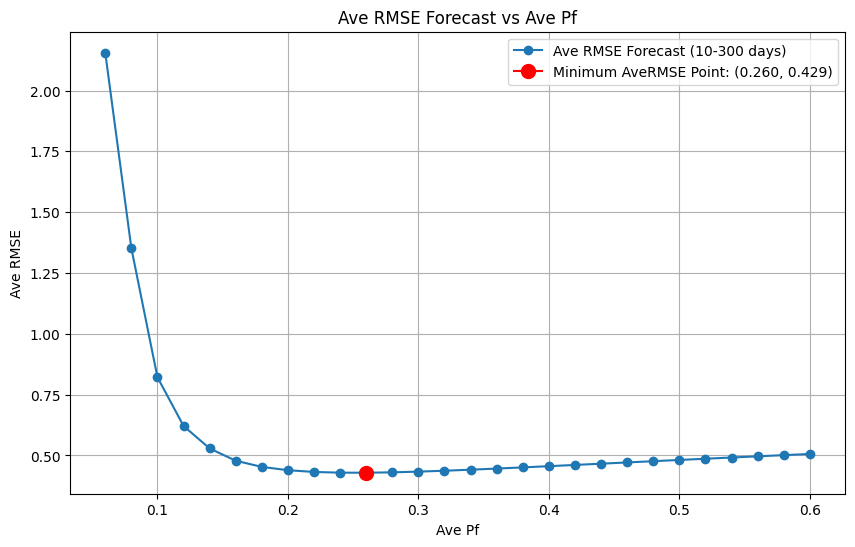

In [ ]:
# ThreeDVarクラスを用いて、forecat_error_std を0から0.6まで0.2刻みで変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
import numpy as np
import matplotlib.pyplot as plt

# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

forecast_error_stds = np.arange(0.06, 0.61, 0.02)

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
for forecast_error_std in forecast_error_stds:
    print(f"\n=== Forecast Error Std: {forecast_error_std} ===")
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=forecast_error_std,use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)

    # 初期状態の設定
    three_d_var.initialize_state(spinup.x.copy())

    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")

    # RMSEの計算
    rmse_analysis, rmse_forecast = three_d_var.compute_rmse(true_states)

    # 結果を保存
    results_dict[forecast_error_std] = {
        'rmse_analysis': rmse_analysis,
        'rmse_forecast': rmse_forecast,
        'p_history': three_d_var.get_P_history()
    }

# プロット
plt.figure(figsize=(10, 6))
plots = []
for forecast_error_std in forecast_error_stds:
    rmse_forecast = results_dict[forecast_error_std]['rmse_forecast']
    days = np.arange(len(observed_states))/ (step_day / assim_interval)
    mask = (days >= 10) & (days <= 300)
    ave_rmse_forecast = np.mean(rmse_forecast[mask])
    plots.append(ave_rmse_forecast)

plt.plot(forecast_error_stds, plots, marker='o', label=f'Ave RMSE Forecast (10-300 days)')
# 最小値のマーキング
min_index = np.argmin(plots)
plt.plot(forecast_error_stds[min_index], plots[min_index], marker='o', color='red', markersize=10, label=f'Minimum AveRMSE Point: ({forecast_error_stds[min_index]:.3f}, {plots[min_index]:.3f})')

plt.xlabel('Ave Pf')
plt.ylabel('Ave RMSE')
plt.title('Ave RMSE Forecast vs Ave Pf')
plt.legend()
plt.grid()
# plt.savefig('result/BasicTask5/Ave_RMSE_vs_Ave_Pf.png')
plt.show()


In [32]:
def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

In [ ]:
def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

In [36]:
H = make_homogeneous_H(n=40, p=30)
print(H)
dense_H = make_dense_H(n=40, p=30)
print(dense_H)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]



=== Number of Observations: 20 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 25 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 0/1460
Assimilating cycle 1

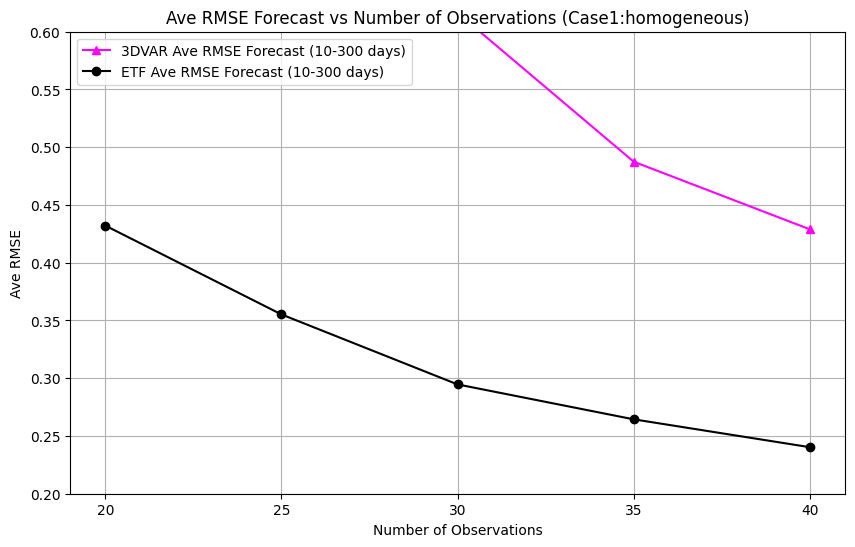

In [73]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_homogeneous_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }
# プロット
plt.figure(figsize=(10, 6))
plots_3dvar = []
plots_etf = []
for p in p_values:
    rmse_forecast_3dvar = results_dict[p]['rmse_forecast_3dvar']
    rmse_forecast_etf = results_dict[p]['rmse_forecast_etf']
    days = np.arange(len(observed_states))/ (step_day / assim_interval)
    mask = (days >= 10) & (days <= 300)
    ave_rmse_forecast_3dvar = np.mean(rmse_forecast_3dvar[mask])
    ave_rmse_forecast_etf = np.mean(rmse_forecast_etf[mask])
    plots_3dvar.append(ave_rmse_forecast_3dvar)
    plots_etf.append(ave_rmse_forecast_etf)
plt.plot(p_values, plots_3dvar, color='magenta', marker='^', label='3DVAR Ave RMSE Forecast (10-300 days)')
plt.plot(p_values, plots_etf, color='black', marker='o', label='ETF Ave RMSE Forecast (10-300 days)')
plt.xlabel('Number of Observations')
plt.xticks(range(20, 41, 5))
plt.ylabel('Ave RMSE')
plt.ylim(0.2, 0.6)
plt.title('Ave RMSE Forecast vs Number of Observations (Case1:homogeneous)')
plt.legend()
plt.grid()
plt.savefig('result/BasicTask5/Ave_RMSE_vs_Num_Observations_case1.png')
plt.show()



=== Number of Observations: 20 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\3890346004.py:16: RuntimeWarning: overflow encountered in scalar multiply
  dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\4194845163.py:114: RuntimeWarning: invalid value encountered in subtract
  M[:, i] = (f_plus - f) / delta
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\4194845163.py:166: RuntimeWarning: overflow encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\4194845163.py:166: RuntimeWarning: invalid value encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\4194845163.py:193: RuntimeWarning: invalid value encountered in matmul
  innovation = H @ observation - H @ self.x_forecast


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\4194845163.py:253: RuntimeWarning: overflow encountered in square
  rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))



=== Number of Observations: 25 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\3890346004.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_24916\3890346004.py:40: RuntimeWarning: invalid value encountered in add
  return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 35 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/146

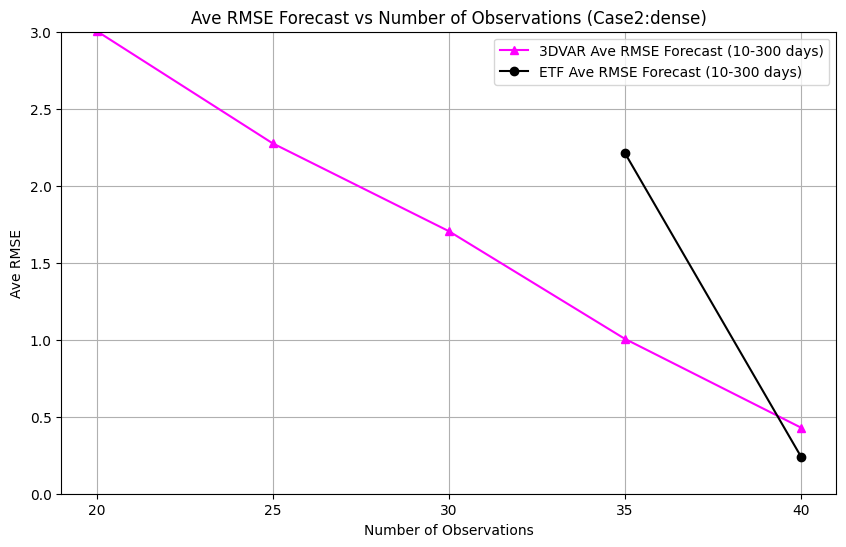

In [72]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_dense_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }
# プロット
plt.figure(figsize=(10, 6))
plots_3dvar = []
plots_etf = []
for p in p_values:
    rmse_forecast_3dvar = results_dict[p]['rmse_forecast_3dvar']
    rmse_forecast_etf = results_dict[p]['rmse_forecast_etf']
    days = np.arange(len(observed_states))/ (step_day / assim_interval)
    mask = (days >= 10) & (days <= 300)
    ave_rmse_forecast_3dvar = np.mean(rmse_forecast_3dvar[mask])
    ave_rmse_forecast_etf = np.mean(rmse_forecast_etf[mask])
    plots_3dvar.append(ave_rmse_forecast_3dvar)
    plots_etf.append(ave_rmse_forecast_etf)
plt.plot(p_values, plots_3dvar, color='magenta', marker='^', label='3DVAR Ave RMSE Forecast (10-300 days)')
plt.plot(p_values, plots_etf, color='black', marker='o', label='ETF Ave RMSE Forecast (10-300 days)')
plt.xlabel('Number of Observations')
plt.xticks(range(20, 41, 5))
plt.ylabel('Ave RMSE')
plt.ylim(0,3)
plt.title('Ave RMSE Forecast vs Number of Observations (Case2:dense)')
plt.legend()
plt.grid()
plt.savefig('result/BasicTask5/Ave_RMSE_vs_Num_Observations_case2.png')
plt.show()